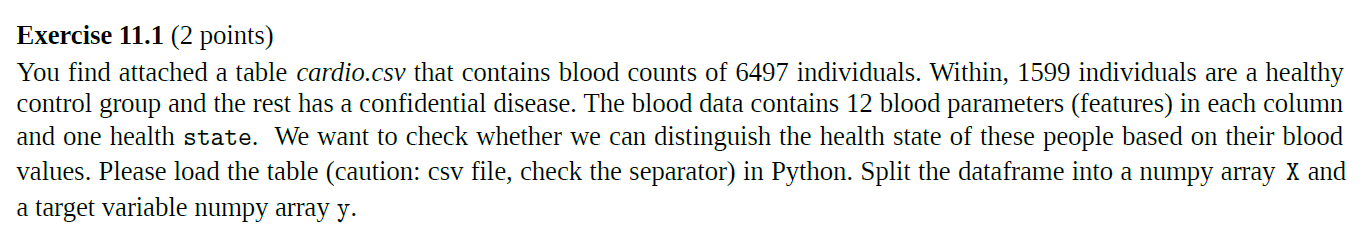

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('cardio.csv', sep = ';')
feat = ["Erythrocytes", "Leukocytes", "Thrombocytes", "Haemoglobin", "Haematokrit", "average_corpus_kulaere_volume", "average_corpuskulaere_Haemoglobin", "density", "average_korpuskulaere_Haemoglobin_concentration", "VLDL", "HDL", "Soberglucose"]

X, y = df.loc[:,feat], df["State"]


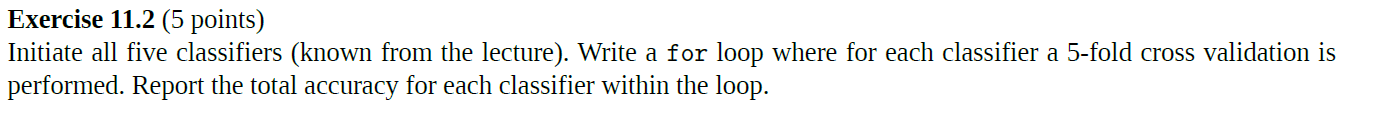

In [ ]:
from sklearn import tree
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import cross_validate

tree_model = tree.DecisionTreeClassifier(random_state = 0)
tree_model.fit(X, y)

svm_model = svm.SVC(kernel = "linear", random_state = 0)
svm_model.fit(X, y)

forest_model = RandomForestClassifier(random_state = 0)
forest_model.fit(X, y)

MLP_model = MLPClassifier(random_state = 0)
MLP_model.fit(X, y)

naive_model = GaussianNB()
naive_model.fit(X, y)

models = [tree_model, svm_model, forest_model, MLP_model, naive_model]
names = ["Decision Tree", "SVM", "Random Forest", "MLP", "Naive Bayes"]

for model, name in zip(models, names):
  cv_results = cross_validate(model, X, y, cv = 5)
  print("Modell: ", name)
  print(cv_results['test_score'])
  total_accuracy = cv_results['test_score'].mean()
  print(total_accuracy)

Modell:  Decision Tree
[0.98538462 0.97461538 0.98152425 0.97767513 0.9730562 ]
0.9784511162432642
Modell:  SVM
[0.98       0.99       0.99307159 0.98460354 0.98537336]
0.9866096997690532
Modell:  Random Forest
[0.99076923 0.99615385 0.99538106 0.98537336 0.99615089]
0.9927656777402735
Modell:  MLP
[0.98076923 0.98461538 0.99230177 0.97690531 0.98691301]
0.9843009415526737
Modell:  Naive Bayes
[0.97153846 0.95461538 0.9799846  0.96689761 0.97228637]
0.9690644874755729


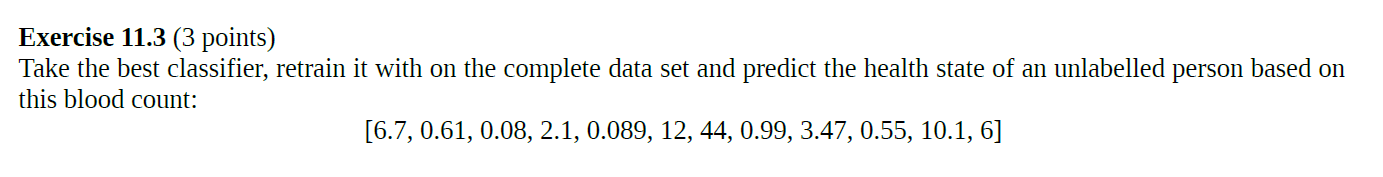

In [ ]:
import numpy as np

unknown = [[6.7, 0.61, 0.08, 2.1, 0.089, 12, 44, 0.99, 3.47, 0.55, 10.1, 6]]

result = forest_model.predict(unknown)
print(result)

['healthy']
